In [ ]:
import torch

def padding_disp_torch(disparity, mask):
    """
    disparity: (H, W), float tensor
    mask:      (H, W), binary float tensor (0 or 1)
    """
    H, W = disparity.shape
    device = disparity.device

    filled_disp = disparity.clone()

    # 마스크가 없는 경우 early return
    if mask.sum() == 0:
        return torch.zeros_like(disparity)

    ys = torch.unique(torch.nonzero(mask, as_tuple=True)[0])

    for y in ys:
        y = y.item()
        row_mask = mask[y] > 0  # (W,)
        if row_mask.sum() == 0:
            continue

        xs = torch.nonzero(row_mask).squeeze(1)  # indices where mask is 1
        x_left, x_right = xs.min().item(), xs.max().item()

        if x_left <= 0 or x_right >= W - 1:
            continue

        left_val = disparity[y, x_left - 1]
        right_val = disparity[y, x_right + 1]

        n = x_right - x_left + 1
        if n <= 0:
            continue

        interp_vals = torch.linspace(left_val, right_val, steps=n, device=device)
        filled_disp[y, x_left:x_right + 1] = interp_vals

    return filled_disp


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from collections import defaultdict
import torch

# 예시: disparity 이미지와 마스크 불러오기
disparity = np.load("/ssd1/jm_data/depth/ssl/depth-hints/depth_hints/2025_03_23/2025_03_23_drive_0006_sync/image_03/0000000001.npy")
mask = cv2.imread("/ssd1/jm_data/Grounded-Segment-Anything/outputs/2025_03_23/2025_03_23_drive_0006_sync/image_03/mask/0000000001.png", cv2.IMREAD_GRAYSCALE) # 유리문 마스크
mask = cv2.resize(mask, (640, 360))
mask = np.where(mask > 50, 255, 0)
# 기존: (1, H, W) → (H, W, 1)
disparity = disparity.transpose(1, 2, 0)
# ✅ 채널 차원 제거 → (H, W)
disparity = np.squeeze(disparity)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(disparity)
plt.subplot(1, 2, 2)
plt.imshow(mask)

def padding_disp(disparity, mask):
    """
    disparity: (H, W), float tensor
    mask:      (1, H, W) or (H, W), binary float tensor (0 or 1)
    """
    H, W = disparity.shape
    device = disparity.device

    if mask.ndim == 3:
        mask = mask.squeeze(0)  # (1, H, W) → (H, W)

    if mask.sum() == 0:
        return torch.zeros_like(disparity), torch.zeros_like(disparity)

    # 마스크가 존재하는 x 영역 확인
    x_indices = torch.nonzero(mask.sum(dim=0) > 0).squeeze(0)
    x_left, x_right = x_indices.min().item(), x_indices.max().item()
    n = x_right - x_left + 1

    if x_left <= 0 or x_right >= W - 1:
        return disparity.clone(), torch.zeros_like(disparity)

    # 마스크가 존재하는 행들
    y_indices = torch.unique(torch.nonzero(mask, as_tuple=True)[0])

    # 좌우 픽셀 값 모으기
    left_vals = []
    right_vals = []

    for y in y_indices:
        y = y.item()
        left_vals.append(disparity[y, x_left - 1].item())
        right_vals.append(disparity[y, x_right + 1].item())

    # 평균 계산
    left_mean = float(torch.tensor(left_vals).mean())
    right_mean = float(torch.tensor(right_vals).mean())

    # 하나의 linspace 생성
    interp_vals = torch.linspace(left_mean, right_mean, steps=n, device=device)

    # 새로운 출력 텐서 생성
    filled_disp = disparity.clone()
    refined_mask = torch.zeros_like(mask, dtype=torch.float32)

    for y in y_indices:
        filled_disp[y, x_left:x_right + 1] = interp_vals
        refined_mask[y, x_left:x_right + 1] = 1.0  # 1로 표시

    # refined_mask > 0인 부분이 interpolation된 영역
    refined_mask = refined_mask.bool()

    # (보간된 영역) - (원래 mask 영역) = 원래 mask 밖에서 보간된 영역
    replace_region = refined_mask & (~mask.bool())

    # 원본 disparity 복구
    filled_disp[replace_region] = disparity[replace_region]

    # replace_pixels: 복구한 부분
    replace_pixels = torch.zeros_like(disparity)
    replace_pixels[replace_region] = disparity[replace_region]

    return filled_disp, replace_pixels, refined_mask



disparity = torch.from_numpy(disparity)
mask = torch.from_numpy(mask)
# print(disparity.shape)
# print(mask.shape)

new_disparity, replace_pixels, refined_mask = padding_disp(disparity, mask)
# print(np.unique(replace_pixels))
# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(disparity, cmap='magma_r')
plt.title("original disparity")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(new_disparity, cmap='magma_r')
plt.title("refined disparity")
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(replace_pixels)
plt.title("replace_pixels")
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(refined_mask)
plt.title("refined_mask")
plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9999843621725064..0.9999996064385525].


cam points : (352, 640, 3)


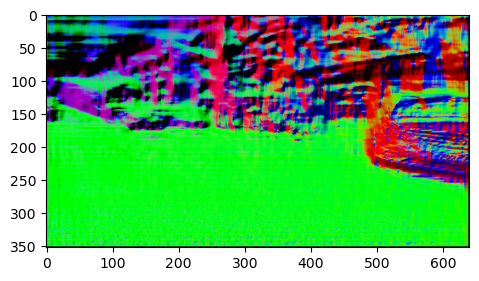

In [103]:
import numpy as np
import matplotlib.pyplot as plt

## Test for all points
K = np.array([[263.9025, 0, 323.5725],
            [0, 263.675, 179.957],
            [0, 0, 1]
            ], dtype=np.float32)

def backproject_depth_numpy(depth, inv_K):
    """
    depth: (H, W) numpy array
    inv_K: (3, 3) numpy array, inverse of camera intrinsic matrix

    returns: (H, W, 3) numpy array of 3D points
    """
    H, W = depth.shape

    # (1) 픽셀 좌표 생성 (u, v)
    u, v = np.meshgrid(np.arange(W), np.arange(H), indexing='xy')
    ones = np.ones_like(u)

    # (2) homogeneous 2D pixel coordinates: shape (3, H*W)
    pix_coords = np.stack([u, v, ones], axis=0).reshape(3, -1)

    # (3) backproject: 3D direction vectors (before scaling by depth)
    cam_dirs = inv_K @ pix_coords  # shape (3, H*W)

    # (4) depth map → 1D
    depth_flat = depth.reshape(-1)  # shape: (H*W,)

    # (5) scale the direction vectors
    cam_points = cam_dirs * depth_flat  # broadcasting → shape (3, H*W)

    # (6) reshape back to (H, W, 3)
    cam_points = cam_points.T.reshape(H, W, 3)

    return cam_points

def normalize_vector(v, eps=1e-8):
    norm = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (norm + eps)

def get_surface_normal_numpy(cam_points, nei=1):
    """
    cam_points: (H, W, 3) numpy array
    return: surface normal map (H, W, 3)
    """
    H, W, _ = cam_points.shape
    pad = nei

    # 중심점 기준 유효 영역
    ctr = cam_points[pad:-pad, pad:-pad]

    x0 = cam_points[pad:-pad, 0:-(2*pad)]
    x1 = cam_points[pad:-pad, 2*pad:]
    y0 = cam_points[0:-(2*pad), pad:-pad]
    y1 = cam_points[2*pad:, pad:-pad]

    x0y0 = cam_points[0:-(2*pad), 0:-(2*pad)]
    x0y1 = cam_points[2*pad:, 0:-(2*pad)]
    x1y0 = cam_points[0:-(2*pad), 2*pad:]
    x1y1 = cam_points[2*pad:, 2*pad:]

    # 벡터 계산
    v_x0 = x0 - ctr
    v_x1 = x1 - ctr
    v_y0 = y0 - ctr
    v_y1 = y1 - ctr

    v_x0y0 = x0y0 - ctr
    v_x0y1 = x0y1 - ctr
    v_x1y0 = x1y0 - ctr
    v_x1y1 = x1y1 - ctr

    # normal 계산 (cross product + normalize)
    n0 = normalize_vector(np.cross(v_x0, v_y0))
    n1 = normalize_vector(np.cross(v_x1, v_y1))
    n2 = normalize_vector(np.cross(v_x0y0, v_x0y1))
    n3 = normalize_vector(np.cross(v_x1y0, v_x1y1))

    normals = normalize_vector((n0 + n1 + n2 + n3) / 4.0)

    # 패딩으로 원래 크기로 복원 (edge는 0으로)
    normal_map = np.zeros_like(cam_points)
    normal_map[pad:-pad, pad:-pad] = normals

    return normal_map

def get_ground_mask_numpy(cam_points, normal_map, threshold_deg=25):
    """
    cam_points: (H, W, 3)
    normal_map: (H, W, 3)
    return: ground_mask (H, W) bool
    """
    H, W = cam_points.shape[:2]

    # 이상적인 ground normal
    ideal = np.array([0.0, 1.0, 0.0])

    # Normalize normal_map
    norm = np.linalg.norm(normal_map, axis=-1, keepdims=True) + 1e-6
    normal_map_normed = normal_map / norm

    # Cosine similarity with vertical
    cos_sim = np.dot(normal_map_normed, ideal)  # (H, W)
    threshold = np.cos(np.radians(threshold_deg))
    vertical_mask = (cos_sim > threshold)

    # Y 좌표 (camera 기준 height)
    y_coords = cam_points[..., 1]
    mask_y = y_coords < -0.3  # 바닥은 음수이고, 너무 가까운 것 제외

    # 이미지 하단 40%만
    row_indices = np.arange(H)
    v_mask = row_indices[:, None] >= int(H * 0.6)  # (H, 1) → broadcast to (H, W)

    v_mask = np.broadcast_to(v_mask, (H, W))  # shape 맞춤

    # 최종 ground mask
    ground_mask = vertical_mask & mask_y & v_mask

    return ground_mask


depth_path = "/ssd1/jm_data/depth/ssl/depth-hints/depth_vis/video/2025_05_08_drive_0004_sync/image_03/0000000270.npy"
# depth = cv2.imread(depth_path, cv2.IMREAD_GRAYSCALE) / 255.0 * d_max
depth = np.load(depth_path)
K_inv = np.linalg.inv(K)
cam_points = backproject_depth_numpy(depth, inv_K=K_inv)
surface_normal = get_surface_normal_numpy(cam_points)

print(f"cam points : {cam_points.shape}")

plt.figure(figsize=(12, 12))
plt.subplot(1,2,1)
plt.imshow(surface_normal)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9999843621725064..0.9999996064385525].


Filtered Normal Vectors (perpendicular to ground):
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)
Mask (True for perpendicular):
tensor([[ True,  True,  True,  ...,  True,  True,  True],
        [ True,  True,  True,  ..., False,  True,  True],
        [ True,  True,  True,  ..., False, False,  True],
        ...,
        [ True, False, False,  ..., False, False,  True],
        [ True, False, False,  ..., False, False,  True],
        [ True,  True,  True,  ...,  True,  True,  True]])
torch.Size([2000, 3])


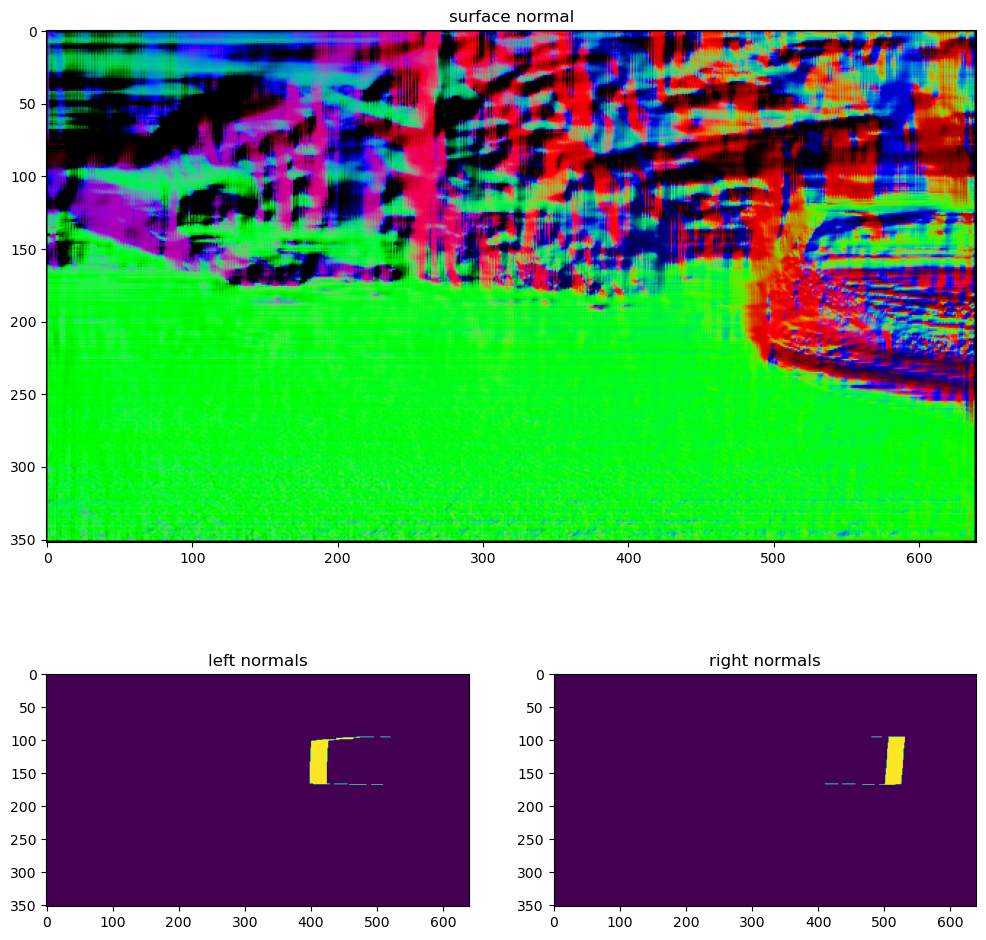

(-0.5, 639.5, 351.5, -0.5)

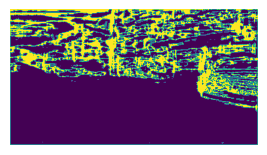

In [165]:

import cv2
import torch
import torch.nn.functional as F

mask = cv2.imread("/ssd1/jm_data/Grounded-Segment-Anything/outputs/2025_05_08/2025_05_08_drive_0004_sync/image_03/mask/0000000270.png", cv2.IMREAD_GRAYSCALE) # 유리문 마스크
mask = cv2.resize(mask, (640, 352))
mask = np.where(mask > 50, 1, 0)
mask = torch.from_numpy(mask)
normal = torch.from_numpy(surface_normal).double()  # float64로 변환

# ground normal vector [0, 1, 0]
ground = torch.tensor([0, 1, 0], dtype=torch.double)  # float64로 변환

# dot_products 계산 (각 normal 벡터와 ground 벡터의 내적)
dot_products = torch.matmul(normal.clone(), ground)

# 내적값이 일정 범위 내에 있는 벡터들만 선택 (수직인 벡터)
threshold = 0.5
ground_vertical_mask = torch.abs(dot_products) < threshold  # 마스크 생성

# 마스크를 사용하여 수직 벡터만 선택
normal_map_vertical = normal.clone()[ground_vertical_mask]

print("Filtered Normal Vectors (perpendicular to ground):")
print(normal_map_vertical)

print("Mask (True for perpendicular):")
print(ground_vertical_mask)

def get_mask_side_regions(mask: torch.Tensor, normals: torch.Tensor, side_width: int = 25, num_samples: int = 2000):
    """
    mask: (H, W), torch.bool or torch.uint8
    normals: (H, W, 3), torch.float
    side_width: 얼마나 넓게 주변을 볼지 (pixels)
    num_samples: 좌우 각각 몇 개의 normal을 샘플링할지
    
    returns:
        left_region_normals: (num_samples, 3)
        right_region_normals: (num_samples, 3)
        left_region: (H, W) mask
        right_region: (H, W) mask
    """
    def sample_normals(mask, normals, num_samples):
        norm_vals = normals[mask]  # (N, 3)
        total = norm_vals.shape[0]
        if total == 0:
            return torch.zeros((num_samples, 3), device=normals.device)
        if total >= num_samples:
            idx = torch.linspace(0, total - 1, steps=num_samples).long()
            return norm_vals[idx]
        else:
            pad = norm_vals[-1].unsqueeze(0).repeat(num_samples - total, 1)
            return torch.cat([norm_vals, pad], dim=0)

    # 1. binary mask float로 변환
    mask_f = mask.float().unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

    # 2. 수직 경계 (좌/우) 검출: x 방향 gradient
    grad_x = F.pad(mask_f, (0, 1, 0, 0))[:, :, :, 1:] - mask_f
    grad_x = grad_x.squeeze(0).squeeze(0)

    left_edge = (grad_x == 1)
    right_edge = (grad_x == -1)

    # 3. dilate: 좌/우 경계 주변 영역 확장
    kernel = torch.ones((1, 1, 1, side_width * 2 + 1), dtype=torch.float32, device=mask.device)
    left_dilate = F.conv2d(left_edge.float().unsqueeze(0).unsqueeze(0), kernel, padding=(0, side_width)).squeeze() > 0
    right_dilate = F.conv2d(right_edge.float().unsqueeze(0).unsqueeze(0), kernel, padding=(0, side_width)).squeeze() > 0

    # 4. mask 영역 밖만 살리기
    not_mask = ~mask.bool()
    left_region = left_dilate & not_mask
    right_region = right_dilate & not_mask

    # 5. sampling된 normal만 반환
    left_normals = sample_normals(left_region, normals, num_samples)
    right_normals = sample_normals(right_region, normals, num_samples)

    return left_normals, right_normals, left_region, right_region

side_normal = get_mask_side_regions(mask, normal)

print(side_normal[0].shape)

# print(side_normal[1].shape)
plt.figure(figsize=(12, 24))
plt.subplot(2,1,1)
plt.title("surface normal")
plt.imshow(normal)
plt.subplot(1,2,1)
plt.imshow(side_normal[2])
plt.title("left normals")
plt.subplot(1,2,2)
plt.imshow(side_normal[3])
plt.title("right normals")
# plt.imshow(mask)
plt.show()
plt.figure(figsize=(12, 6))
plt.subplot(3,1,1)
plt.imshow(ground_vertical_mask)
plt.axis("off")


mean depth : 3.292208671569824


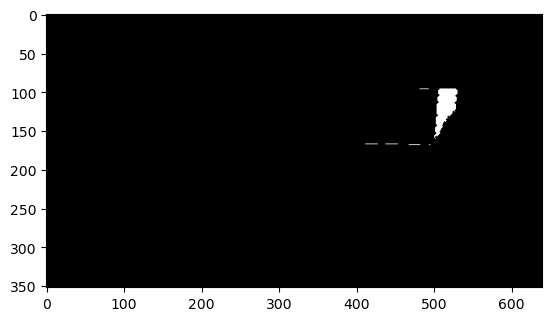

In [ ]:
def shave_side(mask_region: np.ndarray, side: str = 'right', trim_width: int = 50) -> np.ndarray:
    """
    지정된 방향에서 마스크 외곽을 일정 너비만큼 깎는 함수
    - mask_region: 바이너리 마스크 (uint8, 0과 255)
    - side: 'left' 또는 'right'
    - trim_width: 깎을 너비 (픽셀 단위)
    """
    # 윤곽선 찾기
    contours, _ = cv2.findContours(mask_region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 결과 마스크 복사
    trimmed_mask = mask_region.copy()

    for contour in contours:
        contour = contour.squeeze()
        if contour.ndim != 2:
            continue  # contour가 이상한 경우 무시

        if side == 'right':
            edge_points = contour[contour[:, 0] > (np.max(contour[:, 0]) - trim_width)]
        elif side == 'left':
            edge_points = contour[contour[:, 0] < (np.min(contour[:, 0]) + trim_width)]
        else:
            raise ValueError("side must be either 'left' or 'right'.")

        for x, y in edge_points:
            cv2.circle(trimmed_mask, (x, y), radius=1, color=0, thickness=-1)

    return trimmed_mask

left_region, right_region = side_normal[2].detach().cpu().numpy(), side_normal[3].detach().cpu().numpy()

left_region_depth = left_region * depth
right_region_depth = right_region * depth

left_valid_mask = left_region_depth > 0
right_valid_mask = right_region_depth > 0

# print(np.unique(left_region_depth[left_valid_mask]))
# print(np.unique(right_region_depth[right_valid_mask]))
left_mean_depth = np.mean(left_region_depth[left_valid_mask])
right_mean_depth = np.mean(right_region_depth[right_valid_mask])
mean_depth = (left_mean_depth + right_mean_depth) / 4
print(f"mean depth : {mean_depth}")

left_mask = (left_region_depth > mean_depth).astype(np.uint8) * 255
right_mask = (right_region_depth > mean_depth).astype(np.uint8) * 255

right_mask = shave_side(right_mask, side="right")
left_mask = shave_side(left_mask, side="left")

left_mask = torch.from_numpy(left_mask)
right_mask = torch.from_numpy(right_mask)

side_normal = (side_normal[0], side_normal[1], left_mask, right_mask)


# print(np.unique(right_mask))

plt.imshow(right_mask, cmap='gray')
plt.axis('off')

In [ ]:
# import matplotlib.pyplot as plt
# import torch.nn.functional as F

# def visualize_inlier_outlier_on_depth(depth: torch.Tensor, region_mask: torch.Tensor, region_mask_r: torch.Tensor, normals: torch.Tensor, threshold: float = 0.92, num_samples: int = 2000):
#     """
#     depth: (H, W) depth map
#     region_mask: (H, W) bool mask (left_region or right_region)
#     region_mask_r: (H, W) bool mask (right_region)
#     normals: (H, W, 3) surface normal map
#     threshold: cosine similarity 기준
#     num_samples: sampling할 개수
#     """
#     def sample_coords(coords, num_samples):
#         N = coords.shape[0]
#         if N == 0:
#             return coords
#         if N >= num_samples:
#             idx = torch.linspace(0, N-1, steps=num_samples).long()
#             return coords[idx]
#         else:
#             repeat_last = coords[-1].unsqueeze(0).repeat(num_samples - N, 1)
#             return torch.cat([coords, repeat_last], dim=0)

#     # 1. 왼쪽 region
#     coords = torch.nonzero(region_mask, as_tuple=False)  # (N, 2)
#     normal_vals = normals[region_mask]

#     mean_normal = normal_vals.mean(dim=0)
#     mean_normal = mean_normal / mean_normal.norm()

#     cosine_sim = F.cosine_similarity(normal_vals, mean_normal.unsqueeze(0), dim=1)
#     inlier_mask = cosine_sim > threshold

#     coords_inlier = coords[inlier_mask]
#     coords_outlier = coords[~inlier_mask]

#     # 2. 오른쪽 region
#     coords_r = torch.nonzero(region_mask_r, as_tuple=False)
#     normal_vals_r = normals[region_mask_r]

#     mean_normal_r = normal_vals_r.mean(dim=0)
#     mean_normal_r = mean_normal_r / mean_normal_r.norm()

#     cosine_sim_r = F.cosine_similarity(normal_vals_r, mean_normal_r.unsqueeze(0), dim=1)
#     inlier_mask_r = cosine_sim_r > threshold

#     coords_inlier_r = coords_r[inlier_mask_r]
#     coords_outlier_r = coords_r[~inlier_mask_r]

#     # 3. sampling 추가
#     coords_inlier = sample_coords(coords_inlier, num_samples)
#     coords_inlier_r = sample_coords(coords_inlier_r, num_samples)

#     # 4. 시각화
#     # 4. 시각화
#     plt.figure(figsize=(12, 6))

#     if isinstance(depth, torch.Tensor):
#         depth_np = depth.cpu().numpy()
#     else:
#         depth_np = depth

#     plt.imshow(depth_np, cmap='magma_r')  # depth map 배경

#     plt.scatter(coords_inlier[:, 1].cpu(), coords_inlier[:, 0].cpu(), 
#                 c='lime', s=5, alpha=0.9)
#     plt.scatter(coords_outlier[:, 1].cpu(), coords_outlier[:, 0].cpu(), 
#                 c='red', s=5, alpha=0.3)
#     plt.scatter(coords_inlier_r[:, 1].cpu(), coords_inlier_r[:, 0].cpu(), 
#                 c='lime', s=5, alpha=0.9)
#     plt.scatter(coords_outlier_r[:, 1].cpu(), coords_outlier_r[:, 0].cpu(), 
#                 c='red', s=5, alpha=0.3)

#     plt.title("Depth Map with Inlier/Outlier Normals (Sampled)")
#     plt.legend()
#     plt.axis("off")
#     plt.tight_layout()
#     plt.show()


#     return coords_inlier, coords_inlier_r, coords_outlier, coords_outlier_r

# # 예시: 500개로 샘플링
# coords_inlier, coords_inlier_r, coords_outlier, coords_outlier_r = visualize_inlier_outlier_on_depth(
#     depth=depth,
#     region_mask=side_normal[2],
#     region_mask_r=side_normal[3],
#     normals=normal,
#     threshold=0.2,
#     num_samples=2000  # sampling 개수 지정
# )
# print(coords_inlier.shape)  # (500, 2)
# print(coords_inlier_r.shape)  # (500, 2)


/tmp/ipykernel_1826387/2486042669.py:37: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)
  normal_vals = normalized_normal[region_mask]
/tmp/ipykernel_1826387/2486042669.py:45: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:29.)
  normal_vals_r = normalized_normal[region_mask_r]


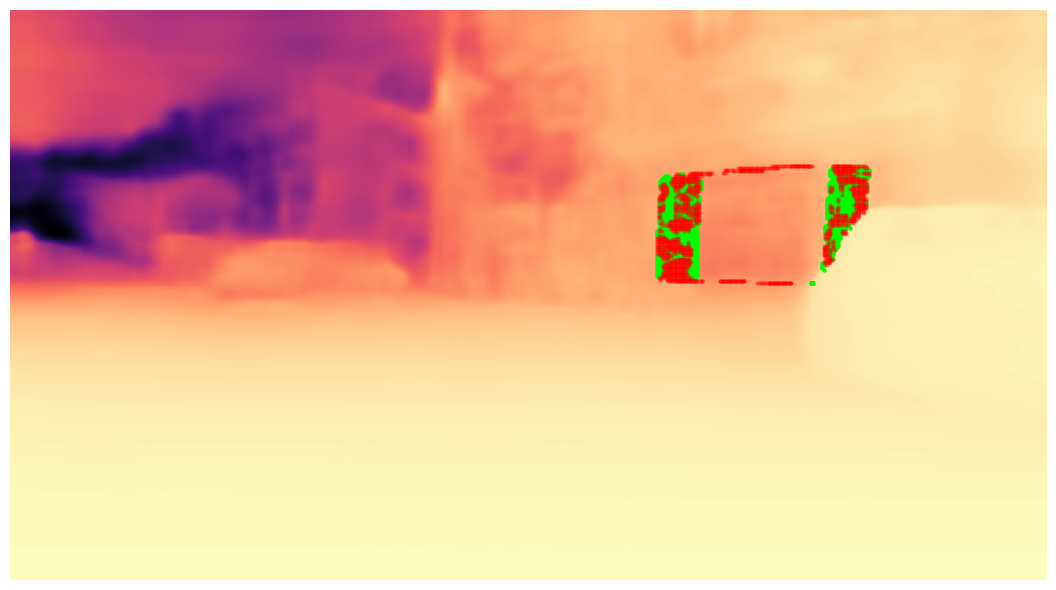

torch.Size([2000, 2])
torch.Size([2000, 2])


In [121]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_inlier_outlier_on_depth(depth: torch.Tensor, region_mask: torch.Tensor, region_mask_r: torch.Tensor,
                                       normals: torch.Tensor, threshold: float = 0.5, num_samples: int = 2000):

    def sample_coords(coords, num_samples):
        N = coords.shape[0]
        if N == 0:
            return coords
        if N >= num_samples:
            idx = torch.linspace(0, N - 1, steps=num_samples).long()
            return coords[idx]
        else:
            repeat_last = coords[-1].unsqueeze(0).repeat(num_samples - N, 1)
            return torch.cat([coords, repeat_last], dim=0)

    # 1. Ideal ground 방향 벡터 [0, 1, 0]
    ideal = torch.tensor([0, 1, 0], dtype=torch.float64)
    normalized_ideal = F.normalize(ideal, dim=0)
    normalized_normal = F.normalize(normals.double(), dim=2)

    # 2. ground candidate들 필터링
    cos_sim = torch.einsum('ijk,k->ij', normalized_normal, normalized_ideal)
    ground_mask = cos_sim > 0.9
    ground_normals = normalized_normal[ground_mask]

    if ground_normals.shape[0] == 0:
        print("No ground points found with cosine similarity > 0.9.")
        return None, None, None, None

    # ground average 방향을 기준 벡터로 사용
    ground_mean = F.normalize(ground_normals.mean(dim=0), dim=0)  # (3,)

    # 3. 왼쪽 region
    coords = torch.nonzero(region_mask, as_tuple=False)
    normal_vals = normalized_normal[region_mask]
    dot_products = torch.matmul(normal_vals, ground_mean)
    inlier_mask = torch.abs(dot_products) < threshold
    coords_inlier = coords[inlier_mask]
    coords_outlier = coords[~inlier_mask]

    # 4. 오른쪽 region
    coords_r = torch.nonzero(region_mask_r, as_tuple=False)
    normal_vals_r = normalized_normal[region_mask_r]
    dot_products_r = torch.matmul(normal_vals_r, ground_mean)
    inlier_mask_r = torch.abs(dot_products_r) < threshold
    coords_inlier_r = coords_r[inlier_mask_r]
    coords_outlier_r = coords_r[~inlier_mask_r]

    # 5. 샘플링
    coords_inlier = sample_coords(coords_inlier, num_samples)
    coords_inlier_r = sample_coords(coords_inlier_r, num_samples)

    # 6. 시각화
    plt.figure(figsize=(12, 6))
    depth_np = depth.cpu().numpy() if isinstance(depth, torch.Tensor) else depth
    plt.imshow(depth_np, cmap='magma_r')

    if coords_inlier.shape[0] > 0:
        plt.scatter(coords_inlier[:, 1].cpu(), coords_inlier[:, 0].cpu(), c='lime', s=5, alpha=0.9, label='Left Inlier')
    if coords_outlier.shape[0] > 0:
        plt.scatter(coords_outlier[:, 1].cpu(), coords_outlier[:, 0].cpu(), c='red', s=5, alpha=0.3, label='Left Outlier')
    if coords_inlier_r.shape[0] > 0:
        plt.scatter(coords_inlier_r[:, 1].cpu(), coords_inlier_r[:, 0].cpu(), c='lime', s=5, alpha=0.9, label='Right Inlier')
    if coords_outlier_r.shape[0] > 0:
        plt.scatter(coords_outlier_r[:, 1].cpu(), coords_outlier_r[:, 0].cpu(), c='red', s=5, alpha=0.3, label='Right Outlier')

    # plt.title("Inlier/outlier region")
    # plt.legend()
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return coords_inlier, coords_inlier_r, coords_outlier, coords_outlier_r

# 예시: 2000개로 샘플링
coords_inlier, coords_inlier_r, coords_outlier, coords_outlier_r = visualize_inlier_outlier_on_depth(
    depth=depth,
    region_mask=side_normal[2],
    region_mask_r=side_normal[3],
    normals=normal,
    threshold=0.5,
    num_samples=2000  # sampling 개수 지정
)

print(coords_inlier.shape)  # (500, 2)
print(coords_inlier_r.shape)  # (500, 2)


defaultdict(<class 'list'>, {101: [413, 414, 415], 102: [404, 405, 406], 103: [403, 404, 405, 406, 407], 104: [402, 403, 404, 405, 406, 407, 408], 105: [401, 402, 403, 404, 405, 406, 407, 426], 106: [401, 402, 403, 404, 405, 406, 407, 417, 421, 423, 424, 425, 426], 107: [401, 405, 406, 407, 417, 418, 420, 421, 422, 426], 108: [405, 406, 407, 408, 415, 416, 417, 418, 419, 420, 421, 426], 109: [401, 406, 407, 408, 409, 413, 415, 416, 417, 418, 421, 426], 110: [406, 407, 408, 409, 411, 413, 414, 415, 416, 417, 421, 426], 111: [406, 407, 408, 409, 411, 413, 414, 415, 416, 421], 112: [406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 421], 113: [406, 407, 408, 409, 410, 411, 413, 415, 417, 418, 419, 421, 423], 114: [405, 406, 407, 408, 409, 410, 411, 413, 418, 419, 420, 421, 423], 115: [405, 406, 407, 408, 409, 411, 413, 419, 420, 421, 422, 423, 425], 116: [401, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 419, 421, 422, 423, 424, 425], 117: [401, 404, 405, 406, 407, 408

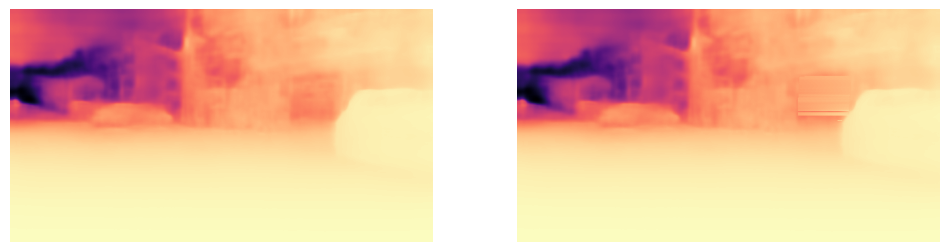

In [122]:
import torch
import torch.nn.functional as F
from collections import defaultdict

def build_y_dict(coords):
    """
    좌표 (N,2)에서 y별로 x를 모아 dictionary로 만듦
    """
    y_dict = defaultdict(list)
    for y, x in coords:
        y = int(y.item())
        x = int(x.item())
        y_dict[y].append(x)
    return y_dict

def interpolate_glass_depth_by_mean(depth, glass_mask, coords_inlier_l, coords_inlier_r):
    """
    depth: (H, W) tensor
    glass_mask: (H, W) binary tensor (1: glass region)
    coords_inlier_l: (N, 2) 왼쪽 inlier 좌표
    coords_inlier_r: (N, 2) 오른쪽 inlier 좌표

    Returns:
        new_depth: (H, W) tensor (보간된 depth)
    """
    H, W = depth.shape
    device = depth.device
    new_depth = depth.clone()

    left_dict = build_y_dict(coords_inlier_l)
    right_dict = build_y_dict(coords_inlier_r)
    
    print(left_dict)
    for y in range(H):
        # 이 y라인에 유리문이 있는지 확인
        x_line = (glass_mask[y] == 1).nonzero(as_tuple=True)[0]
        if len(x_line) == 0:
            continue  # 유리문 없는 줄은 건너뜀

        x_min = x_line.min().item()
        x_max = x_line.max().item()

        # 왼쪽 inlier 평균 x
        left_x_list = left_dict.get(y, [])
        right_x_list = right_dict.get(y, [])

        if len(left_x_list) == 0 or len(right_x_list) == 0:
            continue  # 양쪽 다 있어야 보간 가능

        left_x_mean = sum(left_x_list) / len(left_x_list)
        right_x_mean = sum(right_x_list) / len(right_x_list)

        left_x_mean = int(round(left_x_mean))
        right_x_mean = int(round(right_x_mean))

        # depth 값 가져오기
        left_depth = depth[y, left_x_mean]
        right_depth = depth[y, right_x_mean]

        if torch.isnan(left_depth) or torch.isnan(right_depth):
            continue  # 유효하지 않은 depth는 skip

        # 선형 보간 수행
        for x in range(x_min, x_max + 1):
            if glass_mask[y, x] == 1:
                ratio = (x - left_x_mean) / (right_x_mean - left_x_mean + 1e-6)
                ratio = torch.clamp(torch.tensor(ratio, device=depth.device, dtype=torch.float32), 0.0, 1.0)
                interp_depth = (1 - ratio) * left_depth + ratio * right_depth

                new_depth[y, x] = interp_depth

    return new_depth


# 예시:
depth_torch = torch.from_numpy(depth)
new_depth = interpolate_glass_depth_by_mean(
    depth=depth_torch,
    glass_mask=mask,
    coords_inlier_l=coords_inlier,
    coords_inlier_r=coords_inlier_r
)

# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
# plt.title('Original Depth')
plt.imshow(depth_torch.cpu(), cmap='magma_r')
plt.axis('off')

plt.subplot(1,2,2)
# plt.title('Refined Depth')
plt.imshow(new_depth.cpu(), cmap='magma_r')
plt.axis('off')
plt.show()


Processing cluster 1/1


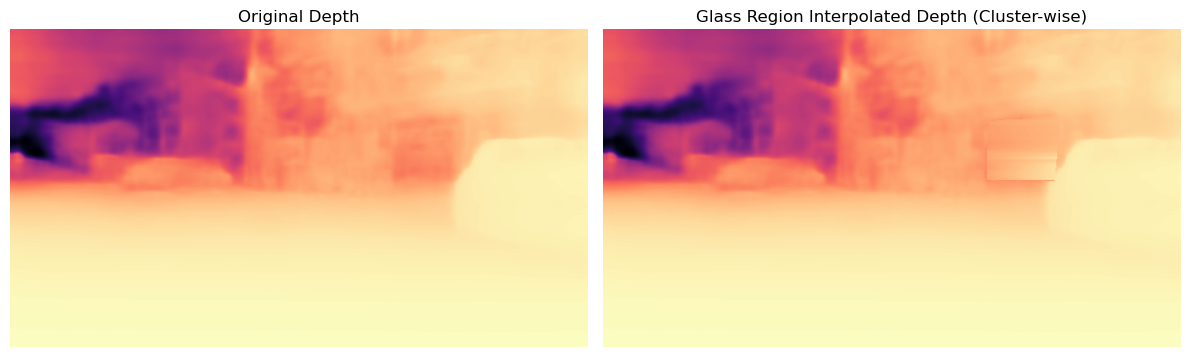

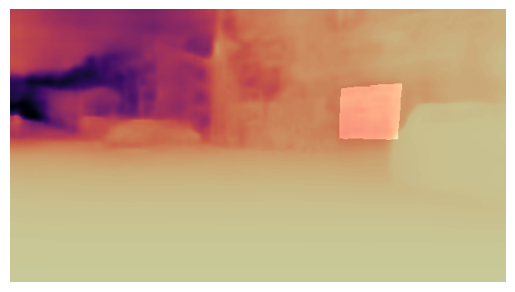

In [59]:
import cv2
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Connected Components 분리 함수 ---
def get_connected_components(mask):
    if isinstance(mask, torch.Tensor):
        mask_np = mask.cpu().numpy().astype(np.uint8)
    else:
        mask_np = mask.astype(np.uint8)

    num_labels, labels = cv2.connectedComponents(mask_np)

    masks = []
    for label in range(1, num_labels):  # 0은 background
        masks.append(torch.from_numpy((labels == label).astype(np.uint8)).to(mask.device))

    return masks

# --- 좌우 벽 영역 normal 추출 함수 ---
def get_mask_side_regions(mask: torch.Tensor, normals: torch.Tensor, side_width: int = 20, num_samples: int = 2000):
    def sample_normals(region_mask, normals, num_samples):
        norm_vals = normals[region_mask]
        total = norm_vals.shape[0]
        if total == 0:
            return torch.zeros((num_samples, 3), device=normals.device)
        if total >= num_samples:
            idx = torch.linspace(0, total-1, steps=num_samples).long()
            return norm_vals[idx]
        else:
            pad = norm_vals[-1].unsqueeze(0).repeat(num_samples - total, 1)
            return torch.cat([norm_vals, pad], dim=0)

    mask_f = mask.float().unsqueeze(0).unsqueeze(0)
    grad_x = F.pad(mask_f, (0, 1, 0, 0))[:, :, :, 1:] - mask_f
    grad_x = grad_x.squeeze(0).squeeze(0)

    left_edge = (grad_x == 1)
    right_edge = (grad_x == -1)

    kernel = torch.ones((1, 1, 1, side_width * 2 + 1), dtype=torch.float32, device=mask.device)
    left_dilate = F.conv2d(left_edge.float().unsqueeze(0).unsqueeze(0), kernel, padding=(0, side_width)).squeeze() > 0
    right_dilate = F.conv2d(right_edge.float().unsqueeze(0).unsqueeze(0), kernel, padding=(0, side_width)).squeeze() > 0

    not_mask = ~mask.bool()
    left_region = left_dilate & not_mask
    right_region = right_dilate & not_mask

    return left_region, right_region

# --- 좌우 normal inlier 좌표 추출 함수 ---
def get_inlier_coords(normals, region_mask, threshold=0.2, num_samples=2000):
    coords = torch.nonzero(region_mask, as_tuple=False)
    if coords.shape[0] == 0:
        return coords

    normal_vals = normals[region_mask]

    mean_normal = normal_vals.mean(dim=0)
    mean_normal = mean_normal / mean_normal.norm()

    cosine_sim = F.cosine_similarity(normal_vals, mean_normal.unsqueeze(0), dim=1)
    inlier_mask = cosine_sim > threshold

    coords_inlier = coords[inlier_mask]

    # sampling
    N = coords_inlier.shape[0]
    if N >= num_samples:
        idx = torch.linspace(0, N-1, steps=num_samples).long()
        coords_inlier = coords_inlier[idx]
    elif N > 0:
        repeat_last = coords_inlier[-1].unsqueeze(0).repeat(num_samples - N, 1)
        coords_inlier = torch.cat([coords_inlier, repeat_last], dim=0)

    return coords_inlier

# --- 보간 함수 ---
def build_y_dict(coords):
    y_dict = defaultdict(list)
    for y, x in coords:
        y = int(y.item())
        x = int(x.item())
        y_dict[y].append(x)
    return y_dict

def interpolate_glass_depth_by_mean(depth, glass_mask, coords_inlier_l, coords_inlier_r):
    H, W = depth.shape
    new_depth = depth.clone()

    left_dict = build_y_dict(coords_inlier_l)
    right_dict = build_y_dict(coords_inlier_r)

    for y in range(H):
        x_line = (glass_mask[y] == 1).nonzero(as_tuple=True)[0]
        if len(x_line) == 0:
            continue

        x_min = x_line.min().item()
        x_max = x_line.max().item()

        left_x_list = left_dict.get(y, [])
        right_x_list = right_dict.get(y, [])

        if len(left_x_list) == 0 or len(right_x_list) == 0:
            continue

        left_x_mean = int(round(sum(left_x_list) / len(left_x_list)))
        right_x_mean = int(round(sum(right_x_list) / len(right_x_list)))

        left_depth = depth[y, left_x_mean]
        right_depth = depth[y, right_x_mean]

        if torch.isnan(left_depth) or torch.isnan(right_depth):
            continue

        for x in range(x_min, x_max + 1):
            if glass_mask[y, x] == 1:
                ratio = (x - left_x_mean) / (right_x_mean - left_x_mean + 1e-6)
                ratio = torch.clamp(torch.tensor(ratio, device=depth.device, dtype=torch.float32), 0.0, 1.0)
                interp_depth = (1 - ratio) * left_depth + ratio * right_depth
                new_depth[y, x] = interp_depth

    return new_depth

# --- 메인 실행 부분 ---
depth_torch = torch.from_numpy(depth).float()
mask_torch = mask.to(torch.bool)
normal_torch = normal.float()

cluster_masks = get_connected_components(mask_torch)

new_depth = depth_torch.clone()

for idx, cluster_mask in enumerate(cluster_masks):
    print(f"Processing cluster {idx+1}/{len(cluster_masks)}")

    left_region, right_region = get_mask_side_regions(cluster_mask, normal_torch, side_width=20, num_samples=2000)

    coords_inlier_l = get_inlier_coords(normal_torch, left_region, threshold=0.2, num_samples=2000)
    coords_inlier_r = get_inlier_coords(normal_torch, right_region, threshold=0.2, num_samples=2000)

    if coords_inlier_l.shape[0] == 0 or coords_inlier_r.shape[0] == 0:
        print(f"Cluster {idx+1}: Skipped due to empty inliers")
        continue

    new_depth = interpolate_glass_depth_by_mean(
        depth=new_depth,
        glass_mask=cluster_mask.bool(),
        coords_inlier_l=coords_inlier_l,
        coords_inlier_r=coords_inlier_r
    )

# --- 결과 시각화 ---
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title('Original Depth')
plt.imshow(depth_torch.cpu(), cmap='magma_r')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Glass Region Interpolated Depth (Cluster-wise)')
plt.imshow(new_depth.cpu(), cmap='magma_r')
plt.axis('off')
plt.tight_layout()
plt.show()

plt.imshow(depth_torch.cpu(), cmap="magma_r")
plt.imshow(mask, cmap="gray", alpha=0.2)
plt.axis('off')
plt.show()
